#### EDA Case Study

**Introduction**

This case study aims to give an idea of applying EDA in a real business scenario. In this case study, we will develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimize the risk of losing money while lending to customers.

**Business Understanding**

The loan providing companies find it hard to give loans to the people due to their insufficient or non-existent credit history. Because of that, some consumers use it as their advantage by becoming a defaulter. Suppose we work for a consumer finance company which specializes in lending various types of loans to urban customers. We will have to use EDA to analyze the patterns present in the data. This will ensure that the applicants capable of repaying the loan are not rejected.

When the company receives a loan application, the company has to decide for loan approval based on the applicant’s profile. Two types of risks are associated with the bank’s decision:

If the applicant is likely to repay the loan, then not approving the loan results in a loss of business to the company

If the applicant is not likely to repay the loan, i.e. he/she is likely to default, then approving the loan may lead to a financial loss for the company.

The data given below contains the information about the loan application at the time of applying for the loan. It contains two types of scenarios:

The client with payment difficulties: he/she had late payment more than X days on at least one of the first Y instalments of the loan in our sample,

All other cases: All other cases when the payment is paid on time.

When a client applies for a loan, there are four types of decisions that could be taken by the client/company):

Approved: The Company has approved loan Application

Cancelled: The client cancelled the application sometime during approval. Either the client changed her/his mind about the loan or in some cases due to a higher risk of the client he received worse pricing which he did not want.

Refused: The company had rejected the loan (because the client does not meet their requirements etc.).

Unused offer: Loan has been cancelled by the client but on different stages of the process.

In this case study, we will use EDA to understand how consumer attributes and loan attributes influence the tendency of default.

**Business Objectives**

This case study aims to identify patterns which indicate if a client has difficulty paying their installments which may be used for taking actions such as denying the loan, reducing the amount of loan, lending (to risky applicants) at a higher interest rate, etc. This will ensure that the consumers capable of repaying the loan are not rejected. Identification of such applicants using EDA is the aim of this case study.

In other words, the company wants to understand the driving factors (or driver variables) behind loan default, i.e. the variables which are strong indicators of default. The company can utilize this knowledge for its portfolio and risk assessment.

**Data Understanding**

This dataset has 3 files as explained below:

`application_data.csv` contains all the information of the client at the time of application.
The data is about whether a client has payment difficulties.

`previous_application.csv` contains information about the client’s previous loan data. It contains the data whether the previous application had been Approved, Cancelled, Refused or Unused offer.

`columns_description.xlsx` is data dictionary which describes the meaning of the variables.


I have given a link to the data files in a drive folder [here](https://drive.google.com/drive/folders/1YpPjU4Y12MPrMdWaNDa6rS2MNirh2FG3?usp=sharing).  I suggest unzipping them and putting them in your google drive, and link to them directly using colab and its "mount drive" functionality.

In [1]:
import requests
import zipfile
import io
import os

# This points to YOUR new repository and username
base_url = 'https://raw.githubusercontent.com/mh7909-cmd/BOOTCAMP_EDA_13/main/files/'

# This creates the local folder in Colab where the files will be saved
if not os.path.exists('/content/bootcamp_data/'):
    os.makedirs('/content/bootcamp_data/')

print("Successfully connected to the BOOTCAMP_EDA_13 repository.")

Successfully connected to the BOOTCAMP_EDA_13 repository.


In [2]:
# Download and unzip the main application data from GitHub
url_app = base_url + 'application_data.csv.zip'
r = requests.get(url_app)

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    z.extractall('/content/bootcamp_data/')

print("Main application data extracted successfully.")

Main application data extracted successfully.


In [3]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/bootcamp_data/application_data.csv')
print(df.head())
df.info()
print(df.describe())

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                 0             

In [4]:
# Download and unzip previous application data + column descriptions
url_prev = base_url + 'previous_application.csv.zip'
url_desc = base_url + 'columns_description.xlsx'

# Extract previous applications zip
r_prev = requests.get(url_prev)
with zipfile.ZipFile(io.BytesIO(r_prev.content)) as z:
    z.extractall('/content/bootcamp_data/')

# Download Excel description file
r_desc = requests.get(url_desc)
with open('/content/bootcamp_data/columns_description.xlsx', 'wb') as f:
    f.write(r_desc.content)

print("Previous data and descriptions extracted.")

Previous data and descriptions extracted.


In [5]:
import numpy as np

dc = pd.read_csv('/content/bootcamp_data/previous_application.csv')
print(dc.head())
dc.info()
print(dc.describe())

   SK_ID_PREV  SK_ID_CURR NAME_CONTRACT_TYPE  AMT_ANNUITY  AMT_APPLICATION  \
0     2030495      271877     Consumer loans     1730.430          17145.0   
1     2802425      108129         Cash loans    25188.615         607500.0   
2     2523466      122040         Cash loans    15060.735         112500.0   
3     2819243      176158         Cash loans    47041.335         450000.0   
4     1784265      202054         Cash loans    31924.395         337500.0   

   AMT_CREDIT  AMT_DOWN_PAYMENT  AMT_GOODS_PRICE WEEKDAY_APPR_PROCESS_START  \
0     17145.0               0.0          17145.0                   SATURDAY   
1    679671.0               NaN         607500.0                   THURSDAY   
2    136444.5               NaN         112500.0                    TUESDAY   
3    470790.0               NaN         450000.0                     MONDAY   
4    404055.0               NaN         337500.0                   THURSDAY   

   HOUR_APPR_PROCESS_START  ... NAME_SELLER_INDUSTRY  CN

In [6]:
# This section summarizes how many applicants defaulted vs repaid and
# calculates the overall default rate to understand class imbalance in the dataset.

target_counts = df['TARGET'].value_counts()
print("Target Counts:")
print(target_counts)

overall_default_rate = df['TARGET'].mean()
print(f"Overall Default Rate: {overall_default_rate:.2%}")

Target Counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64
Overall Default Rate: 8.07%


In [7]:
# This section compares default risk between applicants with higher education
# and secondary education to see whether education level influences repayment
# behavior.

higher_ed = df[df['NAME_EDUCATION_TYPE'] == 'Higher education']
secondary_ed = df[df['NAME_EDUCATION_TYPE'] == 'Secondary / secondary special']

rate_higher = higher_ed['TARGET'].mean()
rate_secondary = secondary_ed['TARGET'].mean()

print(f"Default rate for Higher Education: {rate_higher:.2%}")
print(f"Default rate for Secondary Education: {rate_secondary:.2%}")

Default rate for Higher Education: 5.36%
Default rate for Secondary Education: 8.94%


In [8]:
# This section analyzes differences in default rates between male and female
# applicants to explore potential demographic risk patterns.

male_df = df[df['CODE_GENDER'] == 'M']
female_df = df[df['CODE_GENDER'] == 'F']

rate_male = male_df['TARGET'].mean()
rate_female = female_df['TARGET'].mean()

print(f"Default rate for Males: {rate_male:.2%}")
print(f"Default rate for Females: {rate_female:.2%}")

Default rate for Males: 10.14%
Default rate for Females: 7.00%


In [9]:
# This section identifies the most common applicant occupations and evaluates
# whether certain job types, such as laborers, are associated with higher default
# risk.
top_occupations = df['OCCUPATION_TYPE'].value_counts().nlargest(5)
print("Top 5 Occupations by application volume:")
print(top_occupations)

laborers = df[df['OCCUPATION_TYPE'] == 'Laborers']
print(f"Default rate for Laborers: {laborers['TARGET'].mean():.2%}")

Top 5 Occupations by application volume:
OCCUPATION_TYPE
Laborers       55186
Sales staff    32102
Core staff     27570
Managers       21371
Drivers        18603
Name: count, dtype: int64
Default rate for Laborers: 10.58%


Using the dataset, we created a few research questions to understand how people receive credit and how credit amounts and annuities relate to loan approval outcomes.

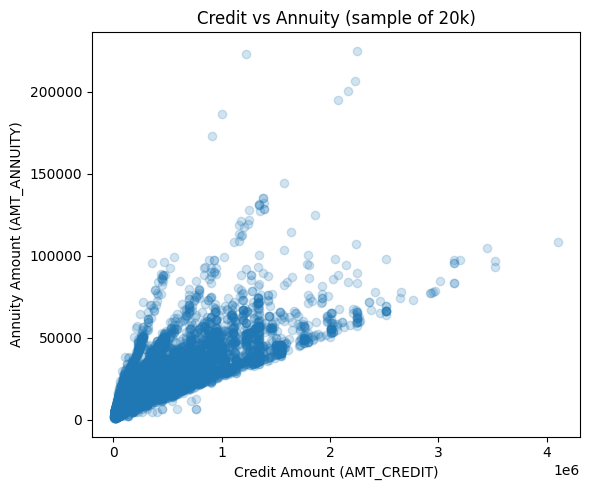

Correlation: 0.816


In [10]:
# Is there a relationship between AMT_CREDIT and AMT_ANNUITY?


# Clean and filter
dc_clean = dc[(dc["AMT_CREDIT"] > 0) & (dc["AMT_ANNUITY"] > 0)].copy()

# Take sample so plot is readable
sample = dc_clean.sample(20000, random_state=42)

# Plot
plt.figure(figsize=(6,5))
plt.scatter(sample["AMT_CREDIT"], sample["AMT_ANNUITY"], alpha=0.2)
plt.xlabel("Credit Amount (AMT_CREDIT)")
plt.ylabel("Annuity Amount (AMT_ANNUITY)")
plt.title("Credit vs Annuity (sample of 20k)")
plt.tight_layout()
plt.show()

# Correlation
print("Correlation:", round(dc_clean["AMT_CREDIT"].corr(dc_clean["AMT_ANNUITY"]), 3))


This graph shows that approval rates vary significantly across different loan contract types. Certain loan types, such as consumer loans, tend to have higher approval rates, while others, such as cash loans, show lower approval rates. This indicates that contract type plays an important role in the company’s risk assessment and approval decisions.

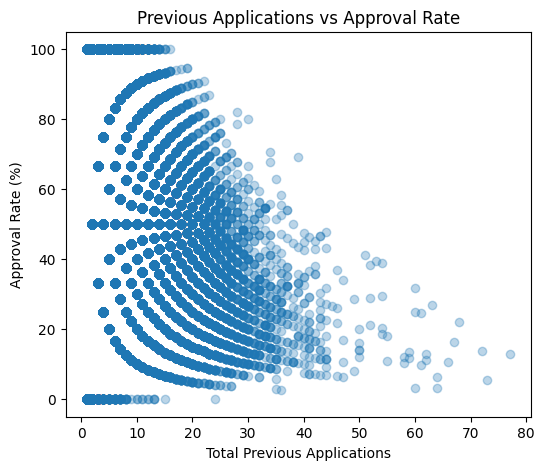

In [ ]:

#Does number of previous applications affect approval rate?

dc["IS_APPROVED"] = (dc["NAME_CONTRACT_STATUS"] == "Approved").astype(int)

client_summary = dc.groupby("SK_ID_CURR").agg(
    total_apps=("SK_ID_PREV", "count"),
    approval_rate=("IS_APPROVED", "mean")
).reset_index()


plt.figure(figsize=(6,5))
plt.scatter(client_summary["total_apps"],
            client_summary["approval_rate"] * 100,
            alpha=0.3)

plt.xlabel("Total Previous Applications")
plt.ylabel("Approval Rate (%)")
plt.title("Previous Applications vs Approval Rate")
plt.show()

This scatterplot shows that approval rates vary depending on the number of previous applications a client has submitted. Clients with only a few applications tend to have extreme approval rates (either very high or very low), while clients with many applications show more moderate and stable approval rates. This pattern reflects how approval rate is calculated and suggests that frequent applicants may have more consistent lending outcomes.

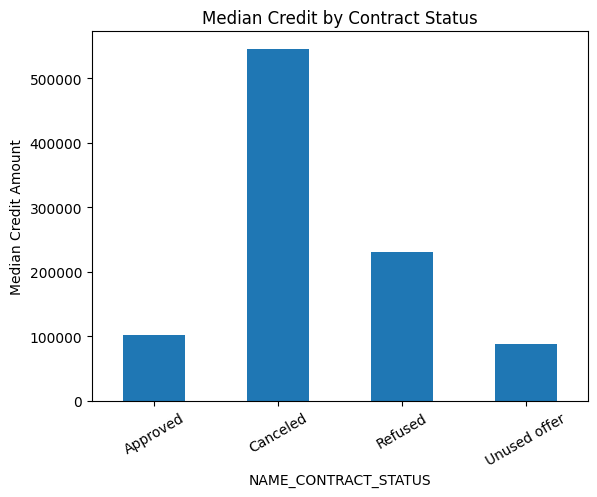

In [ ]:
#Does requested credit amount differ by approval status?
median_credit = (
    dc_clean.groupby("NAME_CONTRACT_STATUS")["AMT_CREDIT"]
    .median()
)

median_credit.plot(kind="bar")
plt.title("Median Credit by Contract Status")
plt.ylabel("Median Credit Amount")
plt.xticks(rotation=30)
plt.show()

This graph shows that median requested credit amounts differ across application outcomes. Refused and canceled applications generally have higher median credit amounts compared to approved applications. This suggests that larger requested loan amounts may be associated with higher perceived risk, increasing the likelihood of rejection or withdrawal during the approval process.

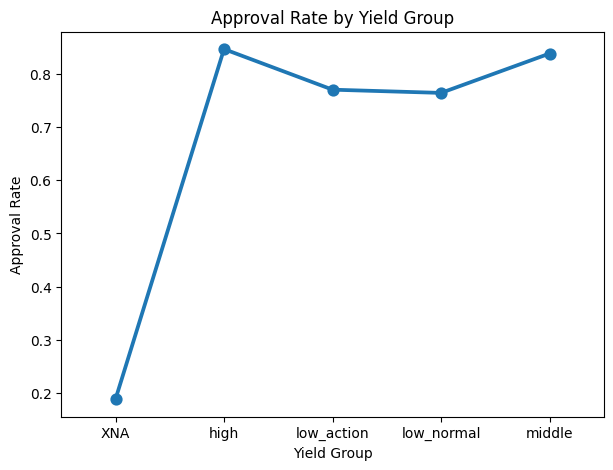

In [ ]:
# Create a binary variable for approval
dc["IS_APPROVED"] = (dc["NAME_CONTRACT_STATUS"] == "Approved").astype(int)

# Compute approval rate for each yield group
yield_rate = (
    dc.groupby("NAME_YIELD_GROUP")["IS_APPROVED"]
      .mean()               # Mean of 1/0 gives approval probability
      .reset_index()
)

# Plot approval rate by yield group
plt.figure(figsize=(7,5))
sns.pointplot(
    data=yield_rate,
    x="NAME_YIELD_GROUP",
    y="IS_APPROVED"
)

plt.title("Approval Rate by Yield Group")
plt.xlabel("Yield Group")
plt.ylabel("Approval Rate")
plt.show()

This graph analyzes how approval probability varies across yield groups, which typically reflect pricing tiers and underlying borrower risk levels. Since higher-yield products are often associated with higher-risk applicants, differences in approval rates across these categories can indicate the presence of risk-based screening and pricing strategies. A decline in approval probability for higher-yield segments would suggest that stricter evaluation standards are applied to riskier borrower groups, highlighting how portfolio segmentation and pricing structure align with institutional risk management practices.

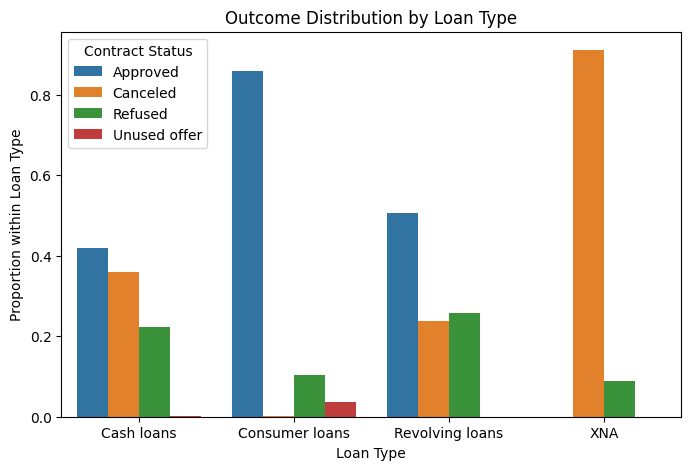

In [ ]:
# Count applications by loan type + contract status
counts = dc.groupby(["NAME_CONTRACT_TYPE", "NAME_CONTRACT_STATUS"]).size()

# Convert to proportions within each loan type
props = counts / counts.groupby(level=0).transform("sum")

# Reset index safely (no name collision)
status_dist = props.rename("proportion").reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=status_dist,
    x="NAME_CONTRACT_TYPE",
    y="proportion",
    hue="NAME_CONTRACT_STATUS"
)

plt.title("Outcome Distribution by Loan Type")
plt.ylabel("Proportion within Loan Type")
plt.xlabel("Loan Type")
plt.legend(title="Contract Status")
plt.show()

This graph examines how different loan types are distributed across all contract outcomes — Approved, Refused, Cancelled, and Unused — rather than focusing only on approval rates. By looking at the proportion of each outcome within each loan category, it becomes possible to see whether certain products systematically experience higher refusal or cancellation rates. Differences in these outcome structures suggest that product type plays a meaningful role in how applications are evaluated, potentially reflecting variations in perceived risk, underwriting standards, or borrower profiles across loan categories.